### Load Libraries and Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATASET_PATH = Path("../../dataset/mesogeos_wildfire_dataset.csv")

df = pd.read_csv(DATASET_PATH)

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (11305, 32)


,date,latitude,longitude,temperature_c,dew_point_c,relative_humidity,wind_speed,wind_direction,rainfall_mm,surface_pressure,...,lc_grassland,lc_settlement,lc_shrubland,lc_sparse_vegetation,lc_water_bodies,lc_wetland,burned_area_ha,year,month,day_of_year
0,2006-08-27,38.123648,-7.819233,36.419031,15.989252,22.510025,3.511700,329.388733,0.000000,99694.617188,...,0.0,0.0,0.000000,0.0,0.0,0.0,40.0,2006,8,239
1,2006-08-11,42.000202,0.447392,27.559045,7.369226,16.027991,6.567619,296.081879,0.004796,93547.523438,...,0.0,0.0,0.192824,0.0,0.0,0.0,1390.0,2006,8,223
2,2006-07-11,41.617581,-8.524061,34.471796,20.400690,35.828364,2.905688,345.955994,0.550396,99709.054688,...,0.0,0.0,0.000000,0.0,0.0,0.0,173.0,2006,7,192
3,2006-09-07,41.557167,-7.567509,30.666193,12.939386,28.009099,2.133366,313.057190,2.396404,93731.859375,...,0.0,0.0,0.000000,0.0,0.0,0.0,220.0,2006,9,250
4,2006-09-08,41.547098,-6.248474,31.690332,14.382166,22.408468,3.914824,288.407166,0.974770,93459.937500,...,0.0,0.0,0.000000,0.0,0.0,0.0,76.0,2006,9,251


### Inspect the dataset structur

In [3]:
print("Rows:", len(df))
print("Columns:", len(df.columns))

df.info()

Rows: 11305
Columns: 32
<class 'pandas.DataFrame'>
RangeIndex: 11305 entries, 0 to 11304
Data columns (total 32 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   date                  11305 non-null  str    
 1   latitude              11305 non-null  float64
 2   longitude             11305 non-null  float64
 3   temperature_c         9844 non-null   float64
 4   dew_point_c           9844 non-null   float64
 5   relative_humidity     9844 non-null   float64
 6   wind_speed            9844 non-null   float64
 7   wind_direction        10891 non-null  float64
 8   rainfall_mm           9844 non-null   float64
 9   surface_pressure      9844 non-null   float64
 10  solar_radiation       9844 non-null   float64
 11  ndvi                  11265 non-null  float64
 12  lai                   11120 non-null  float64
 13  soil_moisture         10171 non-null  float64
 14  elevation             11305 non-null  float64
 15  slope_

### Feature Inventory

In [4]:
feature_inventory = pd.DataFrame({
    "feature": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "missing": df.isna().sum().values,
    "missing_%": (df.isna().mean() * 100).round(2).values,
    "unique_values": df.nunique().values
})

display(feature_inventory)

,feature,dtype,missing,missing_%,unique_values
0,date,str,0,0.00,2819
1,latitude,float64,0,0.00,1347
2,longitude,float64,0,0.00,3431
3,temperature_c,float64,1461,12.92,9780
4,dew_point_c,float64,1461,12.92,9773
5,relative_humidity,float64,1461,12.92,9838
6,wind_speed,float64,1461,12.92,9840
7,wind_direction,float64,414,3.66,10883
8,rainfall_mm,float64,1461,12.92,5239
9,surface_pressure,float64,1461,12.92,9820


## Interpretation — Feature Inventory

The Mesogeos wildfire dataset contains **11,305 observations and 32 variables**.

The dataset contains meteorological, environmental, terrain, land-cover, geographic, and temporal variables that can potentially contribute to wildfire burned-area prediction.

Several meteorological variables, including temperature, dew point, relative humidity, wind speed, rainfall, surface pressure, and solar radiation, contain approximately **12.92% missing observations**. Soil moisture contains approximately **10.03% missing observations**, while LAI, NDVI, and population have considerably smaller amounts of missing data.

Importantly, the target variable `burned_area_ha` contains **no missing values**, meaning that all extracted wildfire records have a known burned-area value.

The land-cover variables contain continuous values between 0 and 1 and therefore appear to represent the proportion or fraction of the corresponding land-cover type within the sampled area rather than simple categorical classes.

The year variable contains 17 distinct years, while the month and day-of-year variables represent temporal information that can later be used for seasonal feature engineering.

At this stage, no observations or variables are removed. The missing values and feature distributions will be investigated further before a preprocessing strategy is selected.

### Investigate Missing Values

In [5]:
weather_cols = [
    "temperature_c",
    "dew_point_c",
    "relative_humidity",
    "wind_speed",
    "wind_direction",
    "rainfall_mm",
    "surface_pressure",
    "solar_radiation"
]

print("Missing weather values by year:")

display(
    df.groupby("year")[weather_cols]
      .apply(lambda x: x.isna().sum())
)

print("\nMissing weather values by month:")

display(
    df.groupby("month")[weather_cols]
      .apply(lambda x: x.isna().sum())
)

Missing weather values by year:


,temperature_c,dew_point_c,relative_humidity,wind_speed,wind_direction,rainfall_mm,surface_pressure,solar_radiation
year,,,,,,,,
2006,44,44,44,44,12,44,44,44
2007,82,82,82,82,33,82,82,82
2008,53,53,53,53,8,53,53,53
2009,62,62,62,62,22,62,62,62
2010,47,47,47,47,13,47,47,47
2011,103,103,103,103,26,103,103,103
2012,146,146,146,146,41,146,146,146
2013,46,46,46,46,14,46,46,46
2014,41,41,41,41,10,41,41,41



Missing weather values by month:


,temperature_c,dew_point_c,relative_humidity,wind_speed,wind_direction,rainfall_mm,surface_pressure,solar_radiation
month,,,,,,,,
1,11,11,11,11,6,11,11,11
2,26,26,26,26,6,26,26,26
3,30,30,30,30,8,30,30,30
4,18,18,18,18,6,18,18,18
5,34,34,34,34,12,34,34,34
6,154,154,154,154,37,154,154,154
7,436,436,436,436,127,436,436,436
8,483,483,483,483,139,483,483,483
9,191,191,191,191,51,191,191,191


## Interpretation — Missing Weather Values

The investigation shows that missing meteorological observations occur throughout the complete 2006–2022 study period rather than being restricted to a single year.

The missing values are also concentrated in the summer months, particularly July and August. However, these months contain substantially more wildfire records than the other months. Therefore, raw missing-value counts alone cannot determine whether the probability of missing data is actually higher during the summer fire season.

The missingness pattern will therefore be evaluated using percentages relative to the number of observations in each year and month.

An additional observation is that `wind_direction` has substantially fewer missing values than the other main meteorological variables. This suggests that different variables may have different missing-data patterns.

At this stage, no missing values are removed or imputed. The missing-data mechanism will be investigated further before selecting an appropriate preprocessing strategy.

### Calculate the missing-data percentages

In [6]:
# MISSING WEATHER PERCENTAGE BY YEAR

year_total = df.groupby("year").size()

year_missing_percent = (
    df.groupby("year")[weather_cols]
      .apply(lambda x: x.isna().mean() * 100)
)

print("Missing weather percentage by year:")
display(year_missing_percent.round(2))

# MISSING WEATHER PERCENTAGE BY MONTH

month_total = df.groupby("month").size()

month_missing_percent = (
    df.groupby("month")[weather_cols]
      .apply(lambda x: x.isna().mean() * 100)
)

print("\nMissing weather percentage by month:")
display(month_missing_percent.round(2))

Missing weather percentage by year:


,temperature_c,dew_point_c,relative_humidity,wind_speed,wind_direction,rainfall_mm,surface_pressure,solar_radiation
year,,,,,,,,
2006,20.56,20.56,20.56,20.56,5.61,20.56,20.56,20.56
2007,13.60,13.60,13.60,13.60,5.47,13.60,13.60,13.60
2008,17.91,17.91,17.91,17.91,2.70,17.91,17.91,17.91
2009,13.60,13.60,13.60,13.60,4.82,13.60,13.60,13.60
2010,11.19,11.19,11.19,11.19,3.10,11.19,11.19,11.19
2011,13.19,13.19,13.19,13.19,3.33,13.19,13.19,13.19
2012,13.96,13.96,13.96,13.96,3.92,13.96,13.96,13.96
2013,10.85,10.85,10.85,10.85,3.30,10.85,10.85,10.85
2014,12.81,12.81,12.81,12.81,3.12,12.81,12.81,12.81



Missing weather percentage by month:


,temperature_c,dew_point_c,relative_humidity,wind_speed,wind_direction,rainfall_mm,surface_pressure,solar_radiation
month,,,,,,,,
1,7.01,7.01,7.01,7.01,3.82,7.01,7.01,7.01
2,6.93,6.93,6.93,6.93,1.60,6.93,6.93,6.93
3,2.93,2.93,2.93,2.93,0.78,2.93,2.93,2.93
4,4.38,4.38,4.38,4.38,1.46,4.38,4.38,4.38
5,17.17,17.17,17.17,17.17,6.06,17.17,17.17,17.17
6,21.78,21.78,21.78,21.78,5.23,21.78,21.78,21.78
7,15.79,15.79,15.79,15.79,4.60,15.79,15.79,15.79
8,13.47,13.47,13.47,13.47,3.88,13.47,13.47,13.47
9,14.55,14.55,14.55,14.55,3.88,14.55,14.55,14.55


## Interpretation — Missing-Data Percentages

The percentage-based analysis shows that missing meteorological observations are distributed across the study period and vary by both year and month.

For the main meteorological variables, annual missingness ranges from approximately 9% to 21%. The highest missing rate occurs in 2006 (20.56%), while 2019 has the lowest rate (9.01%). The `wind_direction` variable has considerably lower missingness, generally remaining below approximately 6%.

Monthly missingness also varies substantially. June has the highest missing rate at approximately 21.78%, followed by May at 17.17%. March has the lowest rate at approximately 2.93%.

Therefore, the missing values do not appear to be uniformly distributed across time. However, the dataset still contains a large number of valid observations and the target variable `burned_area_ha` has no missing values.

The weather variables will therefore be retained. Missing values will be handled during the preprocessing stage using an appropriate imputation strategy. The imputation parameters will be learned only from the training data to prevent data leakage.

No rows are removed at this stage.

### Duplicate Investigation

In [7]:
# Check for completely duplicated records
duplicate_count = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_count}")

if duplicate_count > 0:
    print("\nDuplicate records:")
    display(df[df.duplicated(keep=False)].sort_values(
        by=["date", "latitude", "longitude"]
    ))
else:
    print("No duplicate records found.")

Duplicate rows: 2

Duplicate records:


,date,latitude,longitude,temperature_c,dew_point_c,relative_humidity,wind_speed,wind_direction,rainfall_mm,surface_pressure,...,lc_grassland,lc_settlement,lc_shrubland,lc_sparse_vegetation,lc_water_bodies,lc_wetland,burned_area_ha,year,month,day_of_year
7716,2019-12-30,43.178272,-6.399508,11.799799,4.803339,42.646006,2.036749,181.545166,0.000010,93030.632812,...,0.350848,0.0,0.0,0.0,0.0,0.0,126.0,2019,12,364
8172,2019-12-30,43.178272,-6.399508,11.799799,4.803339,42.646006,2.036749,181.545166,0.000010,93030.632812,...,0.350848,0.0,0.0,0.0,0.0,0.0,126.0,2019,12,364
10087,2021-12-28,43.178272,-6.389439,13.648492,9.709192,73.061812,3.787528,205.027756,0.450703,92098.796875,...,0.035176,0.0,0.0,0.0,0.0,0.0,95.0,2021,12,362
10103,2021-12-28,43.178272,-6.389439,13.648492,9.709192,73.061812,3.787528,205.027756,0.450703,92098.796875,...,0.035176,0.0,0.0,0.0,0.0,0.0,95.0,2021,12,362


## Interpretation — Duplicate Records

The dataset contains **2 exact duplicate records**. Because each duplicate appears twice, four rows are displayed when both copies are shown using `keep=False`.

The duplicated observations correspond to wildfire records dated 2019-12-30 and 2021-12-28. The duplicated rows contain identical values across all 32 columns, including their geographic coordinates, environmental conditions, land-cover information, and burned-area measurements.

These records do not appear to represent separate wildfire events. Keeping duplicate observations could cause certain samples to receive additional weight during model training and may contribute to biased model evaluation, particularly if duplicate observations are distributed between training and testing sets.

Therefore, one copy of each exact duplicate will be removed during the preprocessing stage. The original investigation dataset will remain unchanged at this stage.

### Investigate the target variable

In [8]:
# TARGET VARIABLE — BASIC STATISTICS

target = "burned_area_ha"

print("Target variable:", target)
print("Number of observations:", df[target].count())
print("Missing values:", df[target].isna().sum())

print("\nDescriptive statistics:")
display(df[target].describe())

print("\nSelected percentiles:")
display(
    df[target].quantile(
        [0.50, 0.75, 0.90, 0.95, 0.99, 0.995, 1.00]
    ).rename("burned_area_ha")
)

Target variable: burned_area_ha
Number of observations: 11305
Missing values: 0

Descriptive statistics:


count     11305.000000
mean        489.286953
std        2093.071924
min          30.000000
25%          66.000000
50%         131.000000
75%         335.000000
max      107602.000000
Name: burned_area_ha, dtype: float64


Selected percentiles:


0.500       131.00
0.750       335.00
0.900       868.60
0.950      1665.00
0.990      5900.20
0.995     10197.08
1.000    107602.00
Name: burned_area_ha, dtype: float64

## Interpretation — Target Variable

The target variable `burned_area_ha` contains 11,305 valid wildfire observations and has no missing values.

The distribution is strongly right-skewed. The median burned area is 131 hectares, while the mean is substantially higher at approximately 489 hectares. This difference indicates that a relatively small number of very large wildfire events have a strong influence on the mean.

The percentile analysis further demonstrates the long-tailed nature of the target. Approximately 90% of observations have burned areas below 868.6 hectares, while the 99th percentile is 5,900.2 hectares. However, the maximum recorded burned area is 107,602 hectares.

This indicates the presence of a small number of extreme wildfire events. These observations should not automatically be treated as errors because very large wildfires are physically possible and may represent genuine events.

The strong right-skewness is important for regression modelling because extreme target values can disproportionately influence model training and evaluation. The distribution will therefore be visualized and compared with a logarithmic transformation before deciding how the target should be handled during model development.

### Raw Target Distribution

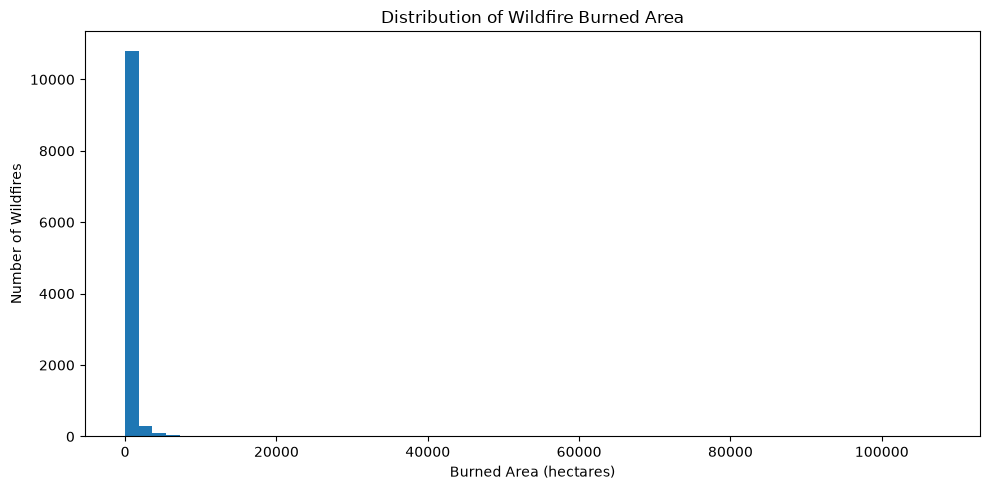

In [13]:
plt.figure(figsize=(10, 5))

plt.hist(df["burned_area_ha"], bins=60)

plt.title("Distribution of Wildfire Burned Area")
plt.xlabel("Burned Area (hectares)")
plt.ylabel("Number of Wildfires")

plt.tight_layout()
plt.show()

## Interpretation — Raw Target Distribution

The histogram confirms that `burned_area_ha` has a strongly right-skewed distribution.

Most wildfire observations are concentrated at relatively small burned-area values, while a small number of observations represent extremely large wildfire events. These extreme observations extend the distribution over a very wide range and make the majority of records difficult to distinguish on the raw scale.

This pattern is consistent with the percentile analysis, where the median burned area is 131 hectares while the maximum reaches 107,602 hectares.

The extreme observations should not automatically be considered errors because they may represent genuine large-scale wildfire events. However, their strong influence on the target distribution may make regression modelling more difficult.

A logarithmic transformation will therefore be investigated as a way of compressing the extreme values and producing a more balanced target distribution for model training.

### Log-transform the target

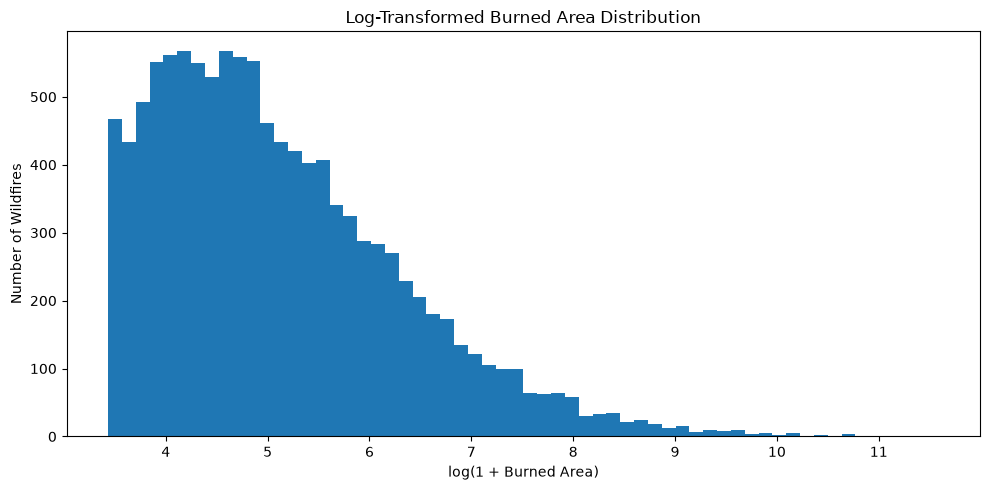

In [14]:
# Log-transformed burned-area distribution

log_burned_area = np.log1p(df["burned_area_ha"])

plt.figure(figsize=(10, 5))

plt.hist(log_burned_area, bins=60)

plt.title("Log-Transformed Burned Area Distribution")
plt.xlabel("log(1 + Burned Area)")
plt.ylabel("Number of Wildfires")

plt.tight_layout()
plt.show()

## Interpretation — Log-Transformed Target

The logarithmic transformation substantially reduces the extreme right-skewness observed in the original `burned_area_ha` distribution.

Using `log1p(burned_area_ha)` compresses very large burned-area values while preserving the ordering of wildfire events. The transformed distribution still has a right tail, but the observations are distributed across the available range much more evenly than in the raw target distribution.

This transformation is therefore a strong candidate for regression model training. It can reduce the disproportionate influence of extremely large wildfire events and may improve the stability of model fitting.

The original burned-area values will still be retained for interpretation and final reporting. If the transformed target is used for modelling, predictions will be converted back to hectares using the inverse transformation `expm1()` so that the final application can report burned area in the original unit.

The decision to use the transformed target will ultimately be validated by comparing model performance using appropriate regression metrics on unseen test data.

### Burned Area by Year

In [15]:
year_burned_area = (
    df.groupby("year")["burned_area_ha"]
      .agg(
          fires="count",
          mean="mean",
          median="median",
          total="sum",
          maximum="max"
      )
      .round(2)
)

display(year_burned_area)

,fires,mean,median,total,maximum
year,,,,,
2006,214,428.07,162.0,91607.0,6837.0
2007,603,893.72,225.0,538911.0,45809.0
2008,296,426.14,158.5,126138.0,16407.0
2009,456,548.53,161.0,250128.0,20521.0
2010,420,382.07,139.0,160470.0,10804.0
2011,781,319.87,131.0,249819.0,6245.0
2012,1046,614.51,192.0,642775.0,32424.0
2013,424,454.92,147.5,192885.0,15015.0
2014,320,401.59,165.0,128509.0,6327.0


### Verify the target maximum

In [16]:
print("Overall maximum:", df["burned_area_ha"].max())

print("\nRows with burned area > 100,000 ha:")
display(
    df[df["burned_area_ha"] > 100000][
        ["date", "latitude", "longitude", "burned_area_ha", "year", "month"]
    ].sort_values("burned_area_ha", ascending=False)
)

Overall maximum: 107602.0

Rows with burned area > 100,000 ha:


,date,latitude,longitude,burned_area_ha,year,month
6183,2017-10-05,40.187787,-7.889716,107602.0,2017,10


### Recalculate the yearly table

In [17]:
year_burned_area = (
    df.groupby("year")["burned_area_ha"]
      .agg(
          fires="count",
          mean="mean",
          median="median",
          total="sum",
          maximum="max"
      )
)

year_burned_area["mean"] = year_burned_area["mean"].round(2)
year_burned_area["median"] = year_burned_area["median"].round(2)
year_burned_area["total"] = year_burned_area["total"].round(2)
year_burned_area["maximum"] = year_burned_area["maximum"].round(2)

display(year_burned_area)

,fires,mean,median,total,maximum
year,,,,,
2006,214,428.07,162.0,91607.0,6837.0
2007,603,893.72,225.0,538911.0,45809.0
2008,296,426.14,158.5,126138.0,16407.0
2009,456,548.53,161.0,250128.0,20521.0
2010,420,382.07,139.0,160470.0,10804.0
2011,781,319.87,131.0,249819.0,6245.0
2012,1046,614.51,192.0,642775.0,32424.0
2013,424,454.92,147.5,192885.0,15015.0
2014,320,401.59,165.0,128509.0,6327.0


In [18]:
print("Overall maximum:", df["burned_area_ha"].max())
print(
    "Maximum yearly value:",
    year_burned_area["maximum"].max()
)

Overall maximum: 107602.0
Maximum yearly value: 107602.0


## Interpretation — Burned Area by Year

The yearly analysis shows substantial variation in wildfire activity between 2006 and 2022. The number of wildfire records varies from 214 observations in 2006 to 1,321 observations in 2017.

The mean burned area is consistently higher than the median in most years, confirming that the target variable is strongly right-skewed and that relatively large wildfire events can substantially influence annual averages.

The year 2017 contains the largest recorded wildfire event in the dataset, with a burned area of 107,602 hectares. However, the median burned area for the same year is only 128 hectares. This demonstrates that extreme wildfire events can have a very large influence on yearly statistics without representing the typical wildfire observation.

The yearly results do not indicate a simple monotonic increase or decrease in wildfire activity over the study period. Instead, both the number of records and burned-area statistics fluctuate considerably between years.

These temporal variations are important for model development. Year and seasonal information may contain useful predictive information, while the strong influence of extreme events supports further consideration of a logarithmic target transformation during regression modelling.

### Burned Area by Month

In [19]:
month_burned_area = (
    df.groupby("month")["burned_area_ha"]
      .agg(
          fires="count",
          mean="mean",
          median="median",
          total="sum",
          maximum="max"
      )
)

month_burned_area["mean"] = month_burned_area["mean"].round(2)
month_burned_area["median"] = month_burned_area["median"].round(2)
month_burned_area["total"] = month_burned_area["total"].round(2)
month_burned_area["maximum"] = month_burned_area["maximum"].round(2)

display(month_burned_area)

,fires,mean,median,total,maximum
month,,,,,
1,157,300.30,99.0,47147.0,6060.0
2,375,244.76,89.0,91785.0,5842.0
3,1025,243.35,105.0,249433.0,6700.0
4,411,280.00,96.0,115081.0,14160.0
5,198,251.67,82.5,49830.0,7005.0
6,707,595.30,140.0,420880.0,46769.0
7,2761,619.56,182.0,1710596.0,54769.0
8,3587,573.64,145.0,2057641.0,51245.0
9,1313,283.33,113.0,372015.0,15536.0


## Interpretation — Burned Area by Month

The monthly analysis demonstrates a strong seasonal pattern in wildfire activity. July and August contain the

### Visualize wildfire frequency by month

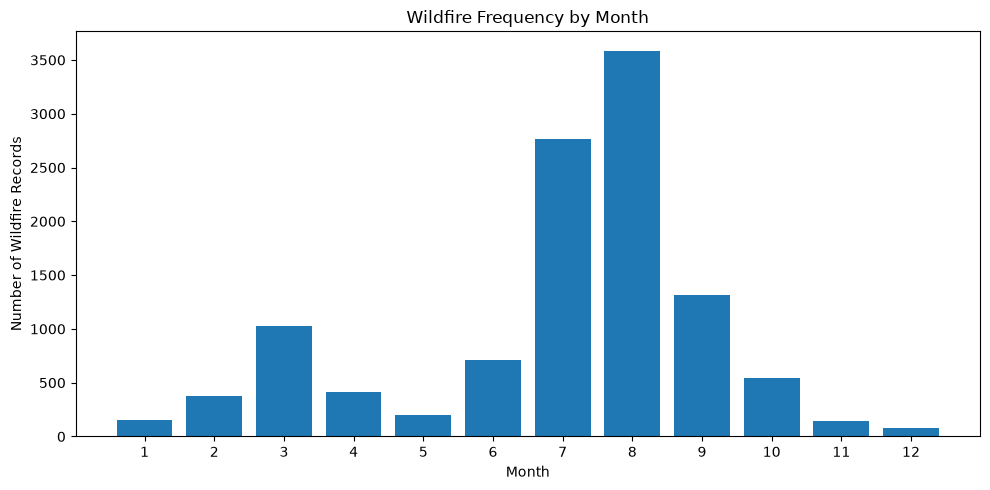

In [21]:
# WILDFIRE FREQUENCY BY MONTH

plt.figure(figsize=(10, 5))

plt.bar(
    month_burned_area.index,
    month_burned_area["fires"]
)

plt.title("Wildfire Frequency by Month")
plt.xlabel("Month")
plt.ylabel("Number of Wildfire Records")

plt.xticks(range(1, 13))

plt.tight_layout()
plt.show()

## Interpretation — Wildfire Frequency by Month

The monthly frequency visualization confirms a strong seasonal concentration of wildfire records.

August has the highest number of wildfire observations, followed by July and September. Together, these summer months account for a substantial proportion of the dataset. In contrast, wildfire records are considerably less frequent during late autumn and winter, particularly November, December, and January.

This seasonal pattern indicates that month and related temporal features may provide useful information for burned-area prediction. However, wildfire frequency should not be confused with wildfire severity. A month with fewer wildfire records can still contain exceptionally large individual fires.

Therefore, both fire frequency and burned-area severity will be considered separately during the remaining exploratory analysis.

### Visualize burned-area severity by month

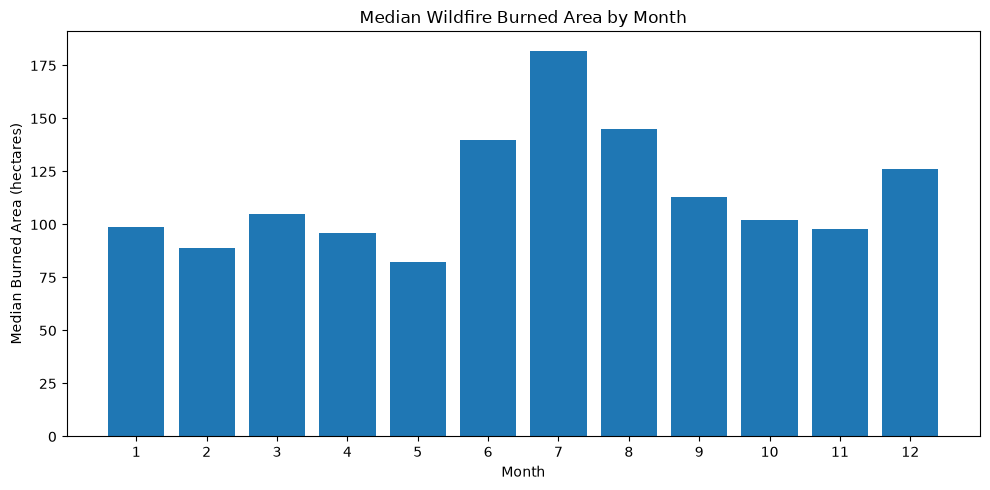

In [22]:
# MEDIAN BURNED AREA BY MONTH

plt.figure(figsize=(10, 5))

plt.bar(
    month_burned_area.index,
    month_burned_area["median"]
)

plt.title("Median Wildfire Burned Area by Month")
plt.xlabel("Month")
plt.ylabel("Median Burned Area (hectares)")

plt.xticks(range(1, 13))

plt.tight_layout()
plt.show()

## Interpretation — Median Burned Area by Month

The median burned-area analysis provides a more robust measure of typical wildfire severity because the target variable contains extreme large-fire observations.

July has the highest median burned area at approximately 182 hectares, followed by August and June. This indicates that fires occurring during the peak summer period tend to have relatively greater typical burned areas.

May has the lowest median burned area at approximately 82 hectares. The relatively moderate median values in several other months indicate that wildfire severity is not determined by season alone.

An important observation is that October contains the overall maximum fire of 107,602 hectares, despite having a median burned area of only approximately 102 hectares. This demonstrates the extreme right-skewness of the target variable and confirms that a small number of exceptionally large fires can occur outside the months with the highest typical fire severity.

Therefore, month may be useful as a predictive feature, but it should be combined with meteorological, vegetation, terrain, and geographical variables.

### Geographic distribution

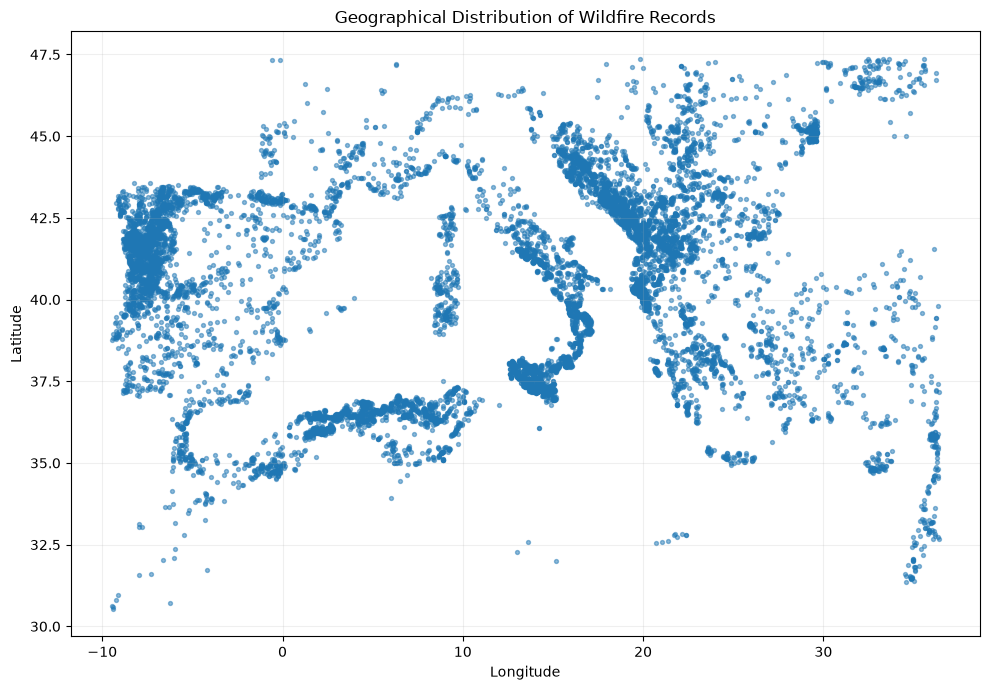

In [23]:
# GEOGRAPHIC DISTRIBUTION OF WILDFIRE RECORDS

plt.figure(figsize=(10, 7))

plt.scatter(
    df["longitude"],
    df["latitude"],
    s=8,
    alpha=0.5
)

plt.title("Geographical Distribution of Wildfire Records")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## Interpretation — Geographical Distribution

The geographical distribution shows that wildfire records are spatially clustered rather than uniformly distributed across the study region.

Several areas contain a much higher concentration of observations, while other areas have relatively few records. This indicates that the dataset has a non-uniform spatial sampling pattern.

Latitude and longitude may therefore provide useful information for predicting burned area because wildfire characteristics can vary geographically due to differences in climate, vegetation, terrain, and human influence.

However, the concentration of observations should not be interpreted directly as wildfire risk. A high number of records in a particular region may partly reflect the availability and coverage of wildfire observations rather than a higher inherent probability of fire.

For the machine-learning stage, geographic coordinates will initially be retained as candidate predictive features. Their contribution will later be evaluated using feature importance and model interpretation techniques.

### Burned area by geographic location

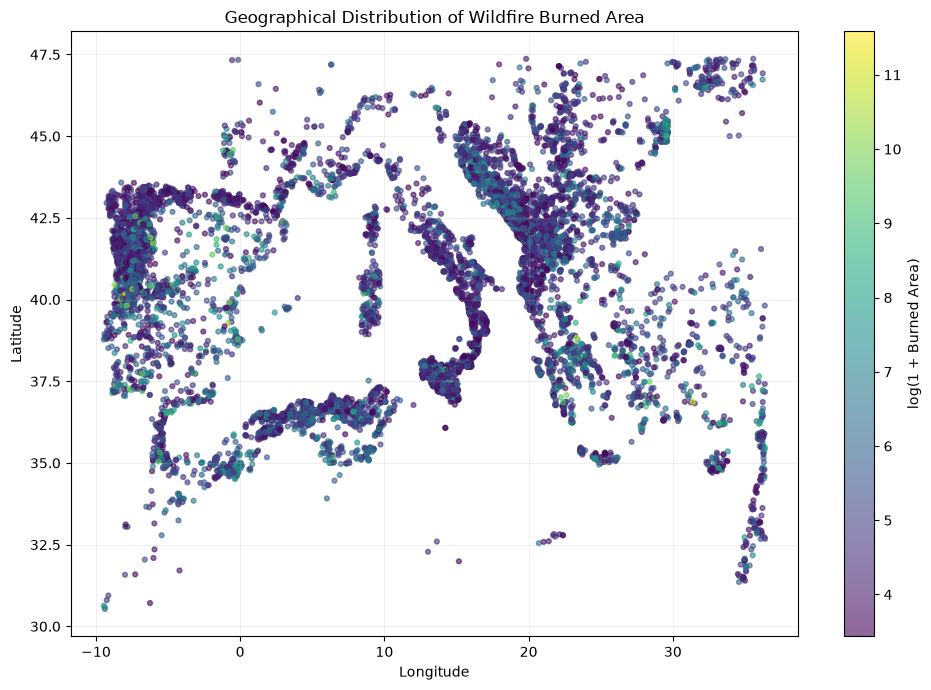

In [24]:
# GEOGRAPHICAL DISTRIBUTION OF BURNED AREA

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    df["longitude"],
    df["latitude"],
    c=np.log1p(df["burned_area_ha"]),
    s=12,
    alpha=0.6
)

plt.colorbar(scatter, label="log(1 + Burned Area)")
plt.title("Geographical Distribution of Wildfire Burned Area")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## Interpretation — Geographical Distribution of Burned Area

The geographical distribution of burned area shows that wildfire severity varies across different parts of the study region.

The use of a logarithmic transformation, `log(1 + burned_area_ha)`, improves the visualization because the burned-area target contains extreme values. The resulting map-like scatter plot shows that larger burned-area observations occur across multiple geographical clusters rather than being restricted to a single location.

This suggests that geographical coordinates may contain useful predictive information. Differences in latitude and longitude can indirectly represent variations in climate, vegetation, terrain, land use, and human influence.

However, the spatial concentration of large fires should not be interpreted as direct evidence that a particular location causes larger fires. The observed pattern may also be influenced by the spatial distribution and sampling of the underlying wildfire records.

Therefore, latitude and longitude will be retained as candidate predictive features and their actual contribution will be evaluated during feature analysis and machine-learning model interpretation.

### CORRELATION WITH BURNED AREA

In [25]:
numeric_df = df.select_dtypes(include=np.number)

# Raw target correlation
raw_correlation = (
    numeric_df.corr()["burned_area_ha"]
    .drop("burned_area_ha")
    .sort_values(key=abs, ascending=False)
)

print("=== CORRELATION WITH RAW BURNED AREA ===")
display(raw_correlation.to_frame("correlation"))

=== CORRELATION WITH RAW BURNED AREA ===


,correlation
relative_humidity,-0.110286
temperature_c,0.091220
wind_speed,0.073741
lc_shrubland,0.058861
solar_radiation,0.050311
soil_moisture,-0.049375
lc_agriculture,-0.049080
month,0.033476
day_of_year,0.033349
latitude,-0.032981


## Interpretation — Correlation with Raw Burned Area

The correlation analysis shows that none of the individual predictor variables has a strong linear relationship with burned area.

Relative humidity has the strongest absolute correlation with the target (r ≈ -0.111), followed by temperature (r ≈ 0.091) and wind speed (r ≈ 0.074). The remaining variables have even weaker linear relationships.

The negative relationship between relative humidity and burned area is consistent with the general expectation that drier atmospheric conditions can support more severe fire behavior. Temperature and wind speed show weak positive relationships with burned area.

However, these correlations should not be interpreted as evidence that the corresponding variables are unimportant. Wildfire severity is influenced by multiple interacting environmental, meteorological, vegetation, terrain, and geographical factors.

The extremely right-skewed distribution of burned area also limits the usefulness of raw Pearson correlation. A small number of exceptionally large fires can strongly influence the correlation coefficients.

Therefore, low individual correlations will not be used as the sole criterion for removing features. The dataset will instead be investigated using the log-transformed target, multivariate modelling, feature importance, and model explainability techniques.

### Correlation with Log-Transformed Burned Area

In [26]:
df["log_burned_area"] = np.log1p(df["burned_area_ha"])

numeric_df = df.select_dtypes(include=np.number)

log_correlation = (
    numeric_df.corr()["log_burned_area"]
    .drop("log_burned_area")
    .sort_values(key=abs, ascending=False)
)

print("=== CORRELATION WITH LOG-TRANSFORMED BURNED AREA ===")

display(
    log_correlation.to_frame("correlation")
)

=== CORRELATION WITH LOG-TRANSFORMED BURNED AREA ===


,correlation
burned_area_ha,0.491469
relative_humidity,-0.241519
temperature_c,0.202301
solar_radiation,0.163584
soil_moisture,-0.138108
wind_speed,0.125820
year,-0.125624
roads_distance_km,0.122214
lc_shrubland,0.113473
ndvi,-0.093957


## Interpretation — Correlation with Log-Transformed Burned Area

The correlation analysis was repeated using the logarithmically transformed target, `log(1 + burned_area_ha)`, to reduce the influence of extreme wildfire observations.

The results reveal stronger relationships than those observed using the raw burned-area values.

Relative humidity has the strongest negative correlation with the transformed target (r ≈ -0.242), while temperature has the strongest positive correlation (r ≈ 0.202). Solar radiation (r ≈ 0.164), soil moisture (r ≈ -0.138), and wind speed (r ≈ 0.126) also show relatively stronger relationships.

These results are consistent with the expected influence of fire-weather conditions. Lower humidity and higher temperature can create drier conditions that are more favorable for wildfire development and spread. Higher solar radiation may also be associated with increased drying of vegetation and surface conditions.

The correlations remain relatively weak overall, demonstrating that wildfire burned area is a complex outcome that cannot be explained by a single environmental variable.

The transformed target provides a more informative representation of the relationships and will therefore be considered during model development. However, correlation measures only linear relationships, so nonlinear machine-learning models will also be evaluated.

The `burned_area_ha` correlation shown in the table itself is excluded from interpretation because it represents the mathematical relationship between the original target and its own log-transformed version.

### Correlation Heatmap

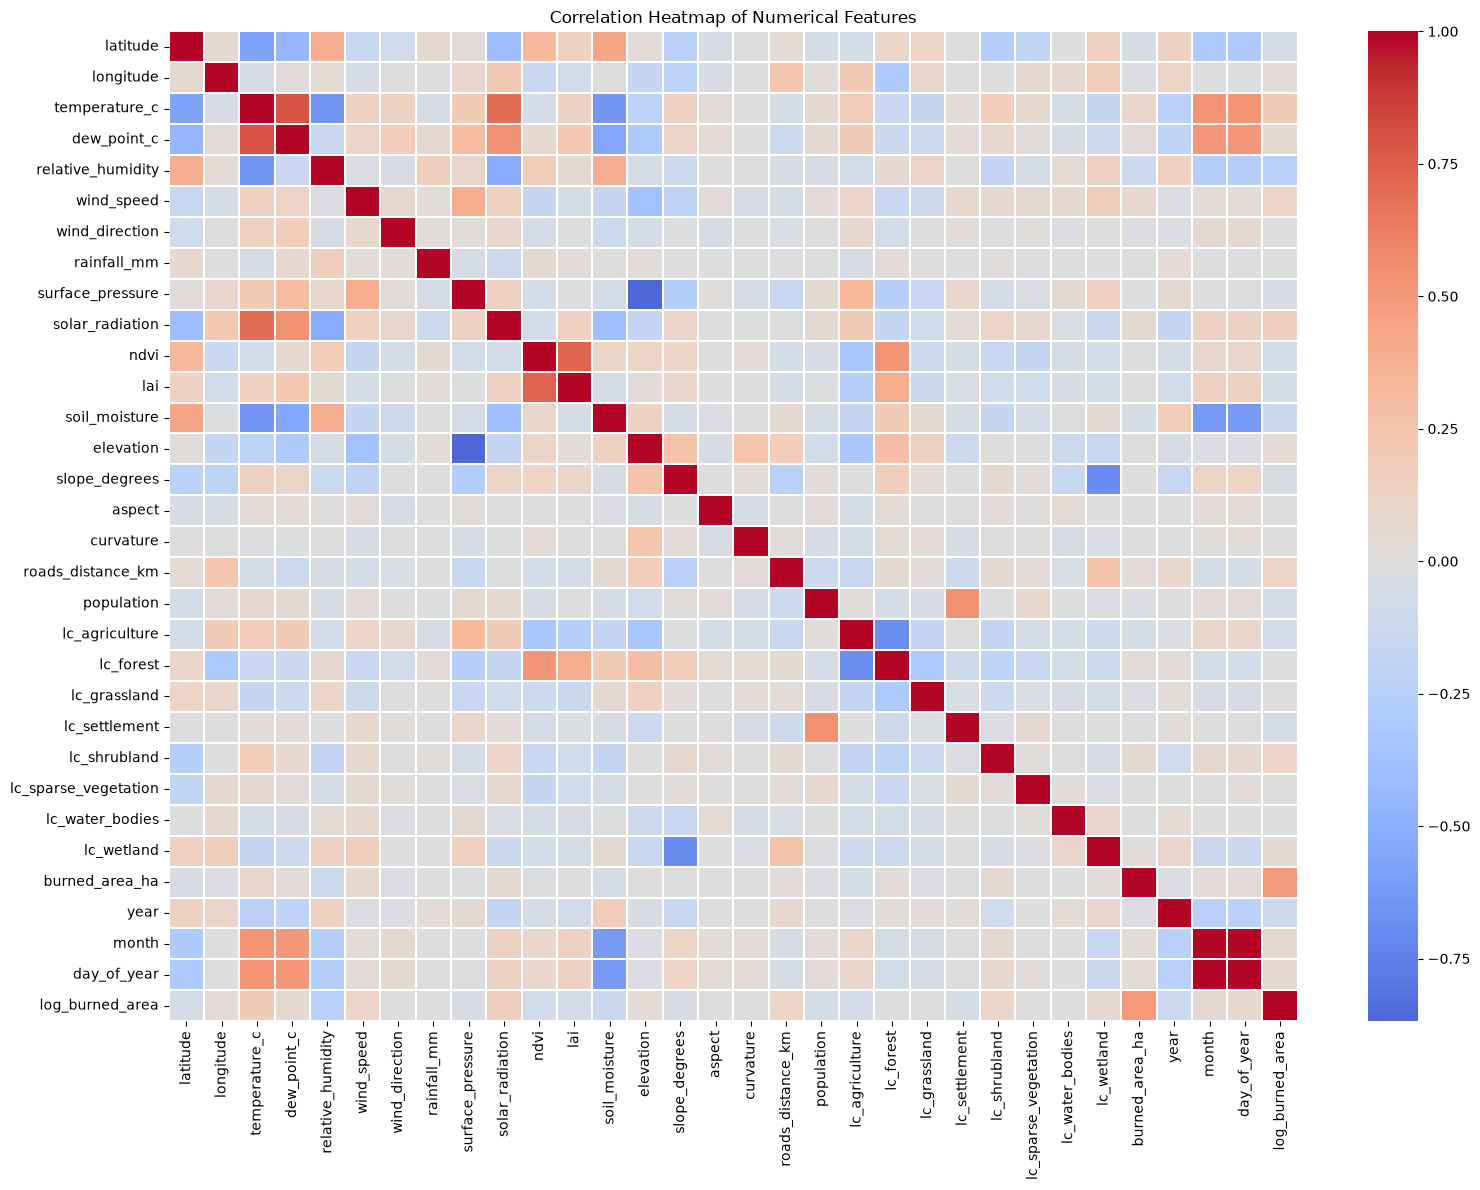

In [27]:
import seaborn as sns

correlation_matrix = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.2
)

plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

## Interpretation — Correlation Heatmap

The correlation heatmap was examined to identify relationships between numerical variables and potential multicollinearity among predictor features.

A relatively strong positive relationship is observed between temperature and dew-point temperature. Temperature also shows a positive relationship with solar radiation. These relationships are physically reasonable because atmospheric and solar conditions are interconnected.

NDVI and LAI also show a positive relationship because both variables describe aspects of vegetation condition.

The land-cover variables exhibit relationships with one another because they represent the composition of the same geographical areas. These relationships are expected and do not automatically indicate problematic redundancy.

A particularly strong relationship is observed between month and day-of-year because both variables represent seasonal timing. This will be considered during feature engineering to avoid unnecessary duplication of seasonal information.

Overall, the heatmap does not indicate severe multicollinearity across the majority of predictor variables. Therefore, no features will be removed solely on the basis of this heatmap. Feature selection will instead be performed using statistical analysis, model-based feature importance, and model performance.